## Data vizualization
In this notebook, I will try toimplement meaningful visualization to better understand the structure of the data from patient 3455.
Inspired from subjects_loop.ipynb

In [1]:
# TODO: - different subjects_dir directories, solve the directories
#      - trans = mne.transforms.Transform('mri', 'head') inconsistent

Imports : 

In [2]:
# General Imports
import os
import numpy as np
import pandas as pd
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import os
from datetime import datetime
import pandas as pd
import numpy as np
import mne
import neo

# MNE imports
import mne
from mne.stats import permutation_cluster_test
from mne import Epochs
from mne.time_frequency import EpochsTFRArray
from mne.datasets import fetch_fsaverage
from mne_bids import (
    find_matching_paths,
    read_raw_bids,
)
import mne_bids
from mne_bids import BIDSPath
from mne.datasets import somato

# Set up the 3D backend for MNE visualization
matplotlib.use('Agg') # or nbAgg
mne.viz.set_3d_backend('notebook')

Using notebook 3d backend.


Useful functions :

In [3]:
EXTRA_COLUMNS_DESCRIPTIONS = {
    'stim_onset_unity': 'Stimulus onset time in seconds since the start of the Unity game',
    'resp_onset_unity': 'Response onset time in seconds since the start of the Unity game',
    'duration': 'Duration between stimulus and response in seconds',
    'condition': 'Condition of the trial (Current, Past, Distant Past, Futur, Distant Futur)',
    'correct': 'Whether the response is correct or not (True/False)',
    'validation': 'whether the response is correct or not(Eprime)',
    'stim': 'Stimulus presented to the subject',
    'resp': 'Response given by the subject',
    'correct_year': 'Year that the subject should have answered',
    'year': 'Year during which the subject was asked to answer',
    'cross_time': 'duration of the fixation cross before trial onset',
}

def raw_from_neo(fname):
    seg_micromed = neo.MicromedIO(filename=fname)
    # Date
    date = seg_micromed.raw_annotations['blocks'][0]['rec_datetime']
    print("Date: ", date)
    # Convert the date to UTC
    segment = seg_micromed.read_segment()

    # Because here we have the same on all chan
    sfreq = segment.analogsignals[0].sampling_rate

    data = np.asarray(segment.analogsignals)[0].T
    data *= 1e-6  # putdata from microvolts to volts

    ch_names = [channel[0] for channel in seg_micromed.header['signal_channels']]
    ch_types = ['stim' if 'MKR' in ch_name else 'ecg' if 'ECG' in ch_name else 'misc' if 'EX' in ch_name else 'stim' if 'PHOTO' in ch_name else 'stim' if 'photo' in ch_name else 'seeg' for ch_name in ch_names]
 
    info = mne.create_info(ch_names, sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(data, info)
    return(raw)


def seeg_ch_name_split(name):
    elec, idx = re.match(r'([A-Za-z]+)(\d+)', name).groups()
    return elec, int(idx)


def find_anodes_cathodes(raw):
    anodes, cathodes = [], []
    for i in range(len(raw.ch_names)-1):
        if raw.get_channel_types()[i:i+2]==['seeg', 'seeg']:
            (e1, i1), (e2, i2) = map(seeg_ch_name_split, raw.ch_names[i:i+2])
            if e1==e2:
                anodes.append(e1 + str(i1))
                cathodes.append(e2 + str(i2))
    return (anodes, cathodes)


def read_montage(subject, subjects_dir):
    # ii. import electrodes
    ch_coords_df = pd.read_csv(os.path.join(subjects_dir, subject, 'elec_recon', subject + '.PIAL'), sep=' ', header=1)
    ch_coords = ch_coords_df[['R', 'A', 'S']].to_numpy(dtype=float)/1000. # put in mm
    ch_names_df = pd.read_csv(os.path.join(subjects_dir, subject, 'elec_recon', subject + '.electrodeNames'), sep=' ', header=1, names=['name', 'Depth', 'hemisphere'])
    ch_names = ch_names_df['name'].tolist()
    ch_pos = dict(zip(ch_names, ch_coords))
    lpa, nasion, rpa = mne.coreg.get_mni_fiducials(subject, subjects_dir=subjects_dir)
    lpa, nasion, rpa = lpa['r'], nasion['r'], rpa['r']
    montage_head = mne.channels.make_dig_montage(ch_pos, coord_frame='mri', nasion=nasion, lpa=lpa, rpa=rpa)
    return(montage_head)


def read_events(fname):
    dicts = list()
    with open(fname) as f:
        content = f.readlines()
        for line in content:
            if line.startswith("UniqueID"):
                ID, Q, year, stim, _, _, _, resp, correct_year, validation, Game, cross_time, stim_onset, resp_time, resp_onset = line.split(" | ")
                
                ID = int(ID.split(":")[1])
                Q = int(Q.split("#")[1])
                year = int(year.split(":")[1])
                stim = stim.split(":")[1]
                resp = resp.split(":")[1].split("(")[0].strip()
                correct_year = correct_year.split(":")[1].strip()
                validation = validation.split(":")[1]
                Game = Game.split("#")[1]
                cross_time = float(cross_time.split(":")[1])
                stim_onset = datetime.strptime(stim_onset.split("displayed:")[1].strip(), "%H:%M:%S:%f")
                resp_time = float(resp_time.split(":")[1])
                resp_onset = datetime.strptime(resp_onset.split("answered:")[1].strip(), "%H:%M:%S:%f")
                data ={
                        "ID": ID,
                        "Q": Q,
                        "year": year,
                        "stim": stim,
                        "resp": resp,
                        "correct_year": correct_year,
                        "validation": validation,
                        "Game": Game,
                        "cross_time": cross_time,
                        "stim_onset": stim_onset,
                        "resp_time": resp_time,
                        "resp_onset": resp_onset
                    }
                dicts.append(data)

    unity_start = content[0].split('|')[0].split('Time:')[1].strip()
    unity_start = datetime.strptime(unity_start, "%H:%M:%S:%f")

    first_photo = content[2].split('completed:')[1].strip()
    first_photo = datetime.strptime(first_photo, "%H:%M:%S:%f")

    df = pd.DataFrame(dicts)

    df['stim_onset_unity'] = df['stim_onset'] - unity_start
    df['stim_onset_unity'] = [stim.total_seconds() for stim in df['stim_onset_unity']]
    df['resp_onset_unity'] = df['resp_onset'] - unity_start
    df['resp_onset_unity'] = [resp.total_seconds() for resp in df['resp_onset_unity']]
    df['duration'] = df['resp_onset_unity'] - df['stim_onset_unity']

    conditions = []
    correct = []
    for r, row in df.iterrows():
        current_year = row['year']
        correct_year = row['correct_year']
        resp = row['resp']
        # Condition
        if correct_year in ['Never', 'Always']:
            condition = correct_year
        else:
            distance = int(correct_year) - int(current_year)
            if distance == 0:
                condition = "Current"
            elif distance == -1:
                condition = "Past"
            elif distance  < -1:
                condition = "Distant Past"
            elif distance == 1:
                condition = "Futur"
            elif distance > 1:
                condition = "Distant Futur"
        conditions.append(condition)

        if resp == 'C':
            response = 'Current'
        elif resp == 'A':
            response = 'Always'
        elif resp == 'N':
            response = 'Never'
        elif resp == '+1':
            response = 'Futur'
        elif resp == '-1':
            response = 'Past'
        elif resp == '+2':
            response = 'Distant Futur'
        elif resp == '-2':
            response = 'Distant Past'
        else:
            raise ValueError(f"Unknown response: {resp}")
        
        if response == condition:
            correct.append(True)
        else:
            correct.append(False)

    df['condition'] = conditions
    df['correct'] = correct
    df['validation'] = df['validation'].astype(bool)

    return(df)

Parameters :

In [46]:
# Choose between TRC data or BIDS data
data_source = "TRC" # "TRC" or "BIDS" or "Check" (for comparing outputs of both)(If check chosen, notebook will be executed with TRC data)

# Electrode Referencing type
# TODO: implement all referencing 
reference = "bipolar" # "bipolar" or "no_reference" or "average" or "all" (with no video rendering)

# Video rendering
video_rendering = False # can be long, so do not do it if not needed
nb_videos = 2 # number of videos to render (usually low to test the pipeline)

# BIDS data already loaded
loaded = True # Can take up ot 15min

# TODO - solve the patient and subject variables, maybe create a mapping between them
patient = "PAT_3455"
subject = "02"


# Check parameters
if data_source not in ["BIDS", "TRC", "Check"]:
    raise ValueError("Data source must be either TRC or BIDS (or Check)")

Process the data :

In [34]:
# BIDS root
bids_root = Path("/media/RCPNAS/sEEG_MARS_Alison")

# FreeSurfer subjects directory - contains reconstructions for all patients, including PAT3455
fs_subjects_dir = Path("/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions") 

# Check participants.tsv for mapping
participants_file = bids_root / "participants.tsv"
if participants_file.exists():
    participants = pd.read_csv(participants_file, sep='\t')
    print("Participants mapping:")
    print(participants)

# Verify the PAT3455 subject exists
pat_path = fs_subjects_dir / patient
print(f"PAT path exists: {pat_path.exists()}")
if pat_path.exists():
    print("Found FreeSurfer subject PAT with directories:")
    print([d.name for d in pat_path.iterdir() if d.is_dir()])

# TODO: Now create mapping for all subjects
subject_to_fs = {
    "02": patient, 
}

# Process sub-02
session = "retrieval"
task = "mars"
fs_subject = subject_to_fs[subject]
print(f"\nProcessing {subject} → FreeSurfer subject: {fs_subject}")
print(f"FreeSurfer directory: {fs_subjects_dir / fs_subject}")

# Create BIDS path from bids_root
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    datatype="ieeg",
    root=bids_root,
    suffix="ieeg",
    extension=".vhdr"
)

if loaded == False : # Skip the loading step if the data is already loaded and cleaned
    # Read data
    if data_source == "BIDS" or data_source == "Check":
        print(f"\nLoading data from: {bids_path.fpath}")
        raw = read_raw_bids(bids_path, verbose=False)
        raw_bids = raw.copy()

    if data_source == "TRC" or data_source == "Check":
        fname_events = fr"/media/RCPNAS/sEEG_MARS_Alison/sourcedata/stims/sub-02/P2/Unity_experiment/Experiment_698092.txt"
        fname_raw = r"/media/RCPNAS/sEEG_MARS_Alison/sourcedata/seeg/sub-02/PA_1987/EEG_6865.TRC"

        print(f"\n--- Traitement TRC ---")
        df = read_events(fname_events)
        raw = raw_from_neo(fname_raw)

        if 'photo' in raw.ch_names:
            raw.rename_channels({'photo': 'photodiode'})
        
        if 'ECG-' in raw.ch_names and 'ECG+' in raw.ch_names:
            raw = mne.set_bipolar_reference(raw, 'ECG-', 'ECG+', ch_name='ECG', drop_refs=True)
            raw.set_channel_types({'ECG': 'ecg'})

        delay = (1844.475 - 333.112) # TODO: Comment est calculé ce délai?
        df['stim_onset_abs'] = df['stim_onset_unity'] + delay
        df['resp_onset_abs'] = df['resp_onset_unity'] + delay

        tmin_abs = 1600
        tmax_abs = 3200
        
        print(f"Durée originale du signal : {raw.times[-1]:.2f}s")
        raw.crop(tmin=tmin_abs, tmax=tmax_abs)
        print(f"Durée après crop ({tmin_abs}-{tmax_abs}) : {raw.times[-1]:.2f}s")

        raw = raw.copy() 

        mask = (df['stim_onset_abs'] >= tmin_abs) & (df['stim_onset_abs'] <= tmax_abs)
        df_filtered = df[mask].reset_index(drop=True)
        
        if len(df_filtered) == 0:
            print(f"ERREUR CRITIQUE : Aucun événement ne tombe dans la fenêtre [{tmin_abs}, {tmax_abs}]s !")
            print(f"Vérifiez vos colonnes 'stim_onset_unity' et le délai calculé ({delay}).")
            print(f"Min stim_onset_abs: {df['stim_onset_abs'].min()}, Max: {df['stim_onset_abs'].max()}")
        else:
            df_filtered['onset_rel'] = df_filtered['stim_onset_abs'] - tmin_abs
            
            onsets = df_filtered['onset_rel'].values
            durations = df_filtered['duration'].values
            descriptions = df_filtered['condition'].values

            valid_idx = ~np.isnan(onsets) & ~np.isnan(durations)
            onsets = onsets[valid_idx]
            durations = durations[valid_idx]
            descriptions = descriptions[valid_idx]

            annotations = mne.Annotations(
                onset=onsets,
                duration=durations,
                description=descriptions.astype(str)
            )
            
            raw.set_annotations(annotations)

            print(f"Nombre d'annotations dans l'objet raw : {len(raw.annotations)}")
            if len(raw.annotations) > 0:
                print(f"Exemple d'annotation : {raw.annotations[0]}")
            else:
                print("ÉCHEC : Les annotations n'ont pas été enregistrées malgré la création.")

        raw_trc = raw.copy()

    trc_channel_names = raw.ch_names
    print(f"TRC channel names (first 10): {trc_channel_names[:10]}")
    print(f"Total channels: {len(trc_channel_names)}")


    # Path to electrode reconstruction files
    elec_recon_path = bids_root / "sourcedata" / "reconstructions" / "PAT_3455" / "elec_recon"
    coord_type = "LEPTO"  # Use LEPTO !!!!!
    coord_file = elec_recon_path / f"PAT_3455.{coord_type}"
    print(f"\nLoading coordinates from: {coord_file}")
    print(f"File exists: {coord_file.exists()}")

    # Load bad annotations
    bad_annotation_path = bids_root / f"sub-{subject}" / f"ses-{session}" / "ieeg" / f"sub-{subject}_ses-{session}_task-{task}_annot.csv"

    if bad_annotation_path.exists():
        # Check if file is empty (size 0) or has only headers
        if bad_annotation_path.stat().st_size == 0:
            print(f"Warning: {bad_annotation_path} is empty. Skipping.")
            bad_annotations = mne.Annotations(onset=[], duration=[], description=[])
        else:
            try:
                # Try reading with pandas first to check content
                df_test = pd.read_csv(bad_annotation_path)
                if df_test.empty:
                    print(f"Warning: {bad_annotation_path} has no data rows. Skipping.")
                    bad_annotations = mne.Annotations(onset=[], duration=[], description=[])
                else:
                    # File has data, proceed with MNE
                    bad_annotations = mne.read_annotations(bad_annotation_path)
                    
                    # Sync orig_time if needed
                    if raw.annotations.orig_time is not None:
                        bad_annotations = mne.Annotations(
                            onset=bad_annotations.onset,
                            duration=bad_annotations.duration,
                            description=bad_annotations.description,
                            orig_time=raw.annotations.orig_time
                        )
            except Exception as e:
                print(f"Error reading {bad_annotation_path}: {e}")
                bad_annotations = mne.Annotations(onset=[], duration=[], description=[])

        # Add to raw
        raw.set_annotations(raw.annotations + bad_annotations)
        print(f"Added {len(bad_annotations)} bad segments.")


    # Clean the coordinates and creates a montage that matches the TRC channels
    if coord_file.exists():
        # Read the coordinate file
        # These are typically text files with coordinates in mm
        coords = []
        with open(coord_file, 'r') as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith('#'):  # Skip empty lines and comments
                    try:
                        # Parse x y z coordinates
                        parts = line.split()
                        if len(parts) >= 3:
                            x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
                            coords.append([x, y, z])
                    except:
                        continue
        
        coords = np.array(coords)
        print(f"Loaded {len(coords)} coordinates")
        
        # Also load electrode names if available
        names_file = elec_recon_path / "PAT_3455.electrodeNames"
        if names_file.exists():
            with open(names_file, 'r') as f:
                electrode_names = [line.strip() for line in f if line.strip() and not line.startswith('#')]
            print(f"Loaded {len(electrode_names)} electrode names")
        else:
            electrode_names = [f"ELEC{i+1:03d}" for i in range(len(coords))]
        
        # Check if number matches TRC channels
        print(f"\nCoordinate count: {len(coords)}")
        print(f"TRC channel count: {len(trc_channel_names)}")
        print(f"Electrode names count: {len(electrode_names)}")
        
        if len(coords) == len(trc_channel_names):
            print(" Coordinate count matches TRC channels - using as-is")
            montage_coords = coords
            montage_names = trc_channel_names
        else:
            print(" Count mismatch - need to map coordinates to TRC channels")
            
            # Create mapping dictionary
            coord_dict = dict(zip(electrode_names, coords))
            
            # Map to TRC order
            montage_coords = []
            montage_names = []
            
            for ch_name in trc_channel_names:
                # Try exact match first
                if ch_name in coord_dict:
                    montage_coords.append(coord_dict[ch_name])
                    montage_names.append(ch_name)
                else:
                    # Try without spaces/special chars
                    ch_clean = ch_name.replace(' ', '').replace('-', '').replace("'", "")
                    found = False
                    for coord_name in coord_dict.keys():
                        coord_clean = coord_name.replace(' ', '').replace('-', '').replace("'", "")
                        if ch_clean in coord_clean or coord_clean in ch_clean:
                            montage_coords.append(coord_dict[coord_name])
                            montage_names.append(ch_name)
                            print(f"  Matched {ch_name} to {coord_name}")
                            found = True
                            break
                    
                    if not found:
                        print(f"  Warning: No match for {ch_name}")
                        montage_coords.append([np.nan, np.nan, np.nan])
                        montage_names.append(ch_name)
            
            montage_coords = np.array(montage_coords)
        montage_coords = montage_coords / 1000  # Convert mm to m for MNE
        
        # Create montage
        montage = mne.channels.make_dig_montage(
            ch_pos=dict(zip(montage_names, montage_coords)),
            coord_frame='mri'  # These are in MRI coordinates
        )
        
        # Set montage to raw
        raw.set_montage(montage)
        print(f"\n✓ Created montage with {len(montage_names)} electrodes")
        
        # Verify first few electrodes
        print("\nFirst 10 electrode positions:")
        for i, ch_name in enumerate(montage_names[:10]):
            pos = montage.get_positions()['ch_pos'][ch_name]
            print(f"  {ch_name}: ({pos[0]}, {pos[1]:.1f}, {pos[2]:.1f})")
        
        # Save montage for future use
        montage_path = Path.cwd() / f"sub-{subject}_montage.fif"
        montage.save(montage_path, overwrite=True)
        print(f"Saved montage to {montage_path}")
        
        # Now you can get volume labels if FreeSurfer subject exists
        fs_subject = "PAT_3455"
        subjects_dir = bids_root / "sourcedata" / "reconstructions"
        
        aparcaseg_path = "/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3455/mri/aparc+aseg.mgz"

        if Path(aparcaseg_path).exists():
            try:
                labels, colors = mne.get_montage_volume_labels(
                    montage,
                    fs_subject,
                    subjects_dir=str(subjects_dir),
                    aseg="aparc+aseg"
                )
                
                # labels and colors are dicts keyed by channel name
                # Build DataFrame from the dicts directly
                results_df = pd.DataFrame({
                    'channel': list(labels.keys()),
                    'label': [labels[ch] for ch in labels.keys()],
                    'color': [colors[ch] for ch in labels.keys()]
                })
                
                output_path = Path.cwd() / f"sub-{subject}_electrode_labels.csv"
                results_df.to_csv(output_path, index=False)
                print(f"Saved electrode labels to {output_path}")
                print(results_df.head())
                
            except Exception as e:
                print(f"Could not get volume labels: {e}")

    if coord_file.exists() == False:
        montage = None

    # Now visualize electrodes on brain
    print(f"\nCreating brain visualization for {fs_subject}")

    # Create brain
    brain = mne.viz.Brain(
        fs_subject,
        subjects_dir=str(fs_subjects_dir),
        cortex="low_contrast",
        alpha=0.25,
        background="white",
        figure=1,
    )

    # Add electrodes if montage exists
    if montage is not None:
        try:
            # TODO: Check the transform
            trans = mne.transforms.Transform('head', 'mri')  # TODO: Why does the inverse trans give the same result
            brain.add_sensors(raw.info, trans=trans)
            print("Added electrodes to brain")
        except Exception as e:
            print(f"Could not add electrodes: {e}")

    print(f"Montage exists: {montage is not None}")

    if montage is None:
        print("\nNo montage found in raw data.")
        print("Looking for electrodes.tsv file...")
        
        # Look for electrodes.tsv
        electrodes_path = bids_root / f"sub-{subject}" / f"ses-{session}" / "ieeg" / f"sub-{subject}_ses-{session}_task-{task}_electrodes.tsv"
        print(f"Electrodes file exists: {electrodes_path.exists()}")
        
        if electrodes_path.exists():
            # Read electrodes.tsv
            electrodes_df = pd.read_csv(electrodes_path, sep='\t')
            print(f"\nElectrodes file contents:")
            print(f"Columns: {electrodes_df.columns.tolist()}")
            print(f"Number of electrodes: {len(electrodes_df)}")
            print("\nFirst few electrodes:")
            print(electrodes_df.head())
            
            # Check coordinate columns
            coord_cols = ['x', 'y', 'z']
            if all(col in electrodes_df.columns for col in coord_cols):
                print("\n✓ Found coordinate columns (x, y, z)")
                
                # Create montage
                montage = mne.channels.make_dig_montage(
                    ch_pos=dict(zip(electrodes_df['name'], 
                                electrodes_df[coord_cols].values)),
                    coord_frame='mri'  # or 'head' - check which one
                )
                raw.set_montage(montage)
                print(f"Created and set montage with {len(electrodes_df)} electrodes")
            else:
                print(f"Expected coordinate columns not found. Available columns: {electrodes_df.columns.tolist()}")
        else:
            print("No electrodes.tsv file found in BIDS directory")
            
            # Look for alternative coordinate files
            coord_files = list(Path(bids_root / f"sub-{subject}").rglob("*coord*"))
            print(f"Alternative coordinate files found: {coord_files}")

    # Save images
    output_dir = Path.cwd() / "figures"
    output_dir.mkdir(exist_ok=True)
    
    # Save different views
    views = [
        ("lateral_right", dict(azimuth=90, elevation=90, distance=400)),
        ("lateral_left", dict(azimuth=-90, elevation=90, distance=400)),
        ("top", dict(azimuth=0, elevation=90, distance=400)),
        ("front", dict(azimuth=0, elevation=0, distance=400)),
        ("back", dict(azimuth=180, elevation=0, distance=400)),
    ]

    for view_name, view_kwargs in views:
        brain.show_view(**view_kwargs)
        output_file = output_dir / "electrodes" /f"{subject}_electrodes_{view_name}.png"
        brain.save_image(str(output_file))
        print(f"Saved: {output_file}")

    brain.close()
    print(f"\nAll images saved to {output_dir}")

if loaded == True:
    #TODO: Get the data from the corresponding path
    empty = 0

Participants mapping:
  participant_id  age  sex  hand  weight  height
0         sub-01  NaN  NaN   NaN     NaN     NaN
1         sub-02  NaN  NaN   NaN     NaN     NaN
2         sub-03  NaN  NaN   NaN     NaN     NaN
3         sub-04  NaN  NaN   NaN     NaN     NaN
4         sub-06  NaN  NaN   NaN     NaN     NaN
PAT path exists: True
Found FreeSurfer subject PAT with directories:
['mri', 'tmp', 'stats', 'surf_old', 'touch', 'trash', 'surf', 'voxeloc', 'elec_recon_pierre_voxeloc', 'label', 'bem', 'mri_old', 'scripts', 'elec_recon', 'label_old', 'elec_recon_old']

Processing 02 → FreeSurfer subject: PAT_3455
FreeSurfer directory: /media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3455

--- Traitement TRC ---
Date:  2022-06-18 09:29:27
Creating RawArray with float64 data, n_channels=121, n_times=8601728
    Range : 0 ... 8601727 =      0.000 ...  4200.062 secs
Ready.
sEEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=86017

/tmp/ipykernel_3997633/1750404541.py:158: RuntimeWarning: Omitted 120 annotation(s) that were outside data range.
  raw.set_annotations(raw.annotations + bad_annotations)
/tmp/ipykernel_3997633/1750404541.py:244: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  raw.set_montage(montage)
/tmp/ipykernel_3997633/1750404541.py:244: RuntimeWarning: Not setting positions of 4 ecg/stim channels found in montage:
['MKR1+', 'photodiode', 'MKR2+', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage)



✓ Created montage with 120 electrodes

First 10 electrode positions:
  AD1: (0.025451764, -0.0, -0.0)
  AD2: (0.028677644999999998, -0.0, -0.0)
  AD3: (0.031903527, -0.0, -0.0)
  AD4: (0.035129409, -0.0, -0.0)
  AD5: (0.038355291, -0.0, -0.0)
  AD6: (0.041581172, 0.0, -0.0)
  AD7: (nan, nan, nan)
  AD8: (nan, nan, nan)
  HAD1: (0.021, -0.0, -0.0)
  HAD2: (0.024277338, -0.0, -0.0)
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Saved montage to /home/aboschun/MIPlab-Project/sub-02_montage.fif


/tmp/ipykernel_3997633/1750404541.py:255: RuntimeWarning: This filename (/home/aboschun/MIPlab-Project/sub-02_montage.fif) does not conform to MNE naming conventions. All montage files should end with -dig.fif or -dig.fif.gz
  montage.save(montage_path, overwrite=True)


Could not get volume labels: 'AD1'

Creating brain visualization for PAT_3455


Channel types::	seeg: 116
Added electrodes to brain
Montage exists: True
Saved: /home/aboschun/MIPlab-Project/figures/electrodes/02_electrodes_lateral_right.png
Saved: /home/aboschun/MIPlab-Project/figures/electrodes/02_electrodes_lateral_left.png
Saved: /home/aboschun/MIPlab-Project/figures/electrodes/02_electrodes_top.png
Saved: /home/aboschun/MIPlab-Project/figures/electrodes/02_electrodes_front.png
Saved: /home/aboschun/MIPlab-Project/figures/electrodes/02_electrodes_back.png

All images saved to /home/aboschun/MIPlab-Project/figures


In [35]:
# Annotations fail if not executed
if data_source == "TRC" or data_source == "Check":
    raw.set_annotations(annotations)
    raw.annotations

In [36]:
if data_source == "Check":
    # Compare BIDS and TRC raw files
    print(raw_bids)
    print(raw_trc)
    # Verify what actually matters
    print(f"Sfreq:    BIDS={raw_bids.info['sfreq']}, TRC={raw_trc.info['sfreq']}")
    print(f"N times:  BIDS={len(raw_bids.times)}, TRC={len(raw_trc.times)}")
    print(f"N ch:     BIDS={len(raw_bids.ch_names)}, TRC={len(raw_trc.ch_names)}")
    print(f"Ch match: {raw_bids.ch_names == raw_trc.ch_names}")
    print(f"Ch types match: {raw_bids.get_channel_types() == raw_trc.get_channel_types()}")

Check montage's electrodes positions and visualize them (all electrodes):

In [37]:
montage.get_positions()

{'ch_pos': OrderedDict([('AD1',
               array([ 0.02545176, -0.00344268, -0.00522475])),
              ('AD2', array([ 0.02867764, -0.00266402, -0.00633712])),
              ('AD3', array([ 0.03190353, -0.00188536, -0.00744949])),
              ('AD4', array([ 0.03512941, -0.00110669, -0.00856186])),
              ('AD5', array([ 0.03835529, -0.00032803, -0.00967424])),
              ('AD6', array([ 0.04158117,  0.00045063, -0.01078661])),
              ('AD7', array([nan, nan, nan])),
              ('AD8', array([nan, nan, nan])),
              ('HAD1', array([ 0.021, -0.019, -0.003])),
              ('HAD2', array([ 0.02427734, -0.01780824, -0.00329794])),
              ('HAD3', array([ 0.02755468, -0.01661648, -0.00359588])),
              ('HAD4', array([ 0.03083201, -0.01542472, -0.00389382])),
              ('HAD5', array([ 0.03410935, -0.01423296, -0.00419176])),
              ('HAD6', array([ 0.03738669, -0.0130412 , -0.0044897 ])),
              ('HAD7', array([ 0.04066

In [38]:
# Get transform and figure
trans = mne.transforms.Transform('mri', 'head')
fig = mne.viz.plot_alignment(
    raw.info,
    trans=trans,         
    subject=fs_subject,
    subjects_dir=subjects_dir,
    surfaces=[],
    coord_frame="mri",
)

# Get picks and brain volume
picks_hip = mne.pick_channels(raw.info['ch_names'], include=montage.ch_names)

brain = mne.viz.Brain(
    fs_subject,
    alpha=0.1,
    cortex="low_contrast",
    subjects_dir=str(fs_subjects_dir), 
    units="m",
    figure=fig,
)
#brain.add_volume_labels(aseg="aparc+aseg", labels=regions_of_interest)

# Add electrode labels
info_hip = mne.pick_info(raw.info, sel=picks_hip)
brain.add_sensors(info_hip, trans=trans)
for idx in picks_hip:
    ch = raw.info['chs'][idx]
    pos = ch['loc'][:3]  # x, y, z in head coords
    brain.plotter.add_point_labels(
        points=[pos],
        labels=[raw.info['ch_names'][idx]],
        point_size=0,
        font_size=12,
        text_color="white",
        shape=None,
        render=False,
    )

# Set and Save views
distance = 0.1
focalpoint = (0.03,-0.0311,0.001)

brain.show_view(azimuth=120, elevation=90)
brain.save_image(f"figures/regions/regions_sub{subject}_alldata01.png")

brain.show_view(azimuth=60, elevation=90)
brain.save_image(f"figures/regions/regions_sub{subject}_alldata02.png")

brain.show_view(azimuth=60, elevation=45)
brain.save_image(f"figures/regions/regions_sub{subject}_alldata03.png")

brain.show_view(azimuth=0, elevation=45)
brain.save_image(f"figures/regions/regions_sub{subject}_alldata04.png")

brain.show_view(azimuth=30, elevation=45)
brain.save_image(f"figures/regions/regions_sub{subject}_alldata05.png")

Channel types::	seeg: 116


A view with name (P_0x7f07bba2bb10_3) is already registered
 => returning previous one


Channel types::	seeg: 116


My theory: We see that IPD14 and IPD15 have nan positions and that the AD shaft contains 6 electrodes but has 8 labels. The last two ADs were out of the brain so they were deleted but stayed in the process somehow which then moves all the electrodes. Lets change this. I added NaNs coordinates for AD7 and AD8 from the electrodenames file. This solves the problem for now, please check with Pierre? for mor details.

Keep electrodes that are relevant to our study (hippocampus region) :

In [39]:
aseg = "aparc+aseg"  # parcellation/anatomical segmentation atlas
path_atlas = "/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions"

# Get volume labels for each electrode based on the montage and FreeSurfer subject
labels, colors = mne.get_montage_volume_labels(
    montage, patient, subjects_dir=path_atlas, aseg=aseg
)
print(f"Labels: {labels}")

# Separate by electrodes which have names like LAMY 1
electrodes = set(
    [
        "".join([lttr for lttr in ch_name if not lttr.isdigit() and lttr != " "])
        for ch_name in montage.ch_names
    ]
)
print(f"Electrodes in the dataset: {electrodes}")

# Define regions of interest (ROIs) to keep
regions_of_interest = {
    "ctx-rh-parahippocampal",
    "ctx-rh-fusiform",
    "Right-Hippocampus",
    "ctx-lh-parahippocampal",
    "ctx-lh-fusiform",
    "Left-Hippocampus",
}

# Get labels that correspond to the ROIs --> electrodes that are in the regions of interest
filtered_labels = {
    ch: region_list
    for ch, region_list in labels.items()
    if any(r in regions_of_interest for r in region_list)
}

print(f"Kept {len(filtered_labels)}/{len(labels)} electrodes")
for ch, regions in filtered_labels.items():
    print(f"  {ch}: {regions}")

# New set of electrodes that have labels in the ROIs
filtered_electrodes = set([ch.split(" ")[0] for ch in filtered_labels.keys()])
filtered_channels = list(filtered_labels.keys()) 

# Plot their ROIs
fig, ax = mne.viz.plot_channel_labels_circle(filtered_labels, colors, picks=list(filtered_electrodes))
fig.text(0.3, 0.9, "Anatomical Labels", color="white")
fig.savefig(f"figures/electrodes/{subject}_allelec_labels.png", dpi=300)

Labels: OrderedDict({'AD1': ['Right-Cerebral-White-Matter', 'Right-Amygdala'], 'AD2': ['Right-Cerebral-White-Matter'], 'AD3': ['Right-Cerebral-White-Matter'], 'AD4': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'AD5': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'AD6': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'AD7': [], 'AD8': [], 'HAD1': ['Right-Cerebral-White-Matter', 'Right-Hippocampus'], 'HAD2': ['Right-Cerebral-White-Matter', 'Right-Hippocampus'], 'HAD3': ['Right-Cerebral-White-Matter', 'Right-Inf-Lat-Vent', 'Right-Hippocampus'], 'HAD4': ['Right-Cerebral-White-Matter', 'Right-Inf-Lat-Vent', 'Right-Hippocampus', 'ctx-rh-fusiform'], 'HAD5': ['Unknown', 'Right-Cerebral-White-Matter', 'Right-Inf-Lat-Vent'], 'HAD6': ['Right-Cerebral-White-Matter'], 'HAD7': ['Right-Cerebral-White-Matter'], 'HAD8': ['Right-Cerebral-White-Matter', 'ctx-rh-inferiortemporal'], 'HAD9': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'HAD10': ['Right-Cerebr

Filter the raw data of the relevant electrodes :

In [40]:
raw_filtered = raw.copy().pick_channels(filtered_electrodes) # TODO : test with all electrodes
# Filter raw signals
raw_filtered.load_data()

# band-pass filter 0.1 < 250 Hz
raw_filtered.filter(.1, 250, picks='seeg', fir_design='firwin', n_jobs=9)

# remove power line 50 Hz and harmonics
for ifreq in np.arange(50, 251, 100): # TODO: might be sufficient to filter every 100Hz
    raw_filtered.notch_filter(ifreq, 
                     picks='seeg', 
                     notch_widths=4,
                     method='iir', 
                     iir_params={'order':6, 'ftype':'butter'},
                     n_jobs=9)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 2.5e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 250.00 Hz
- Upper transition bandwidth: 62.50 Hz (-6 dB cutoff frequency: 281.25 Hz)
- Filter length: 67585 samples (33.000 s)



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:   23.6s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:   26.0s remaining:    8.0s
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:   27.6s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 48 - 52 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)
- Cutoffs at 47.50, 52.50 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    5.1s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    6.4s remaining:    2.0s
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    9.7s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 1.5e+02 - 1.5e+02 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)
- Cutoffs at 147.50, 152.50 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    7.5s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    9.0s remaining:    2.8s
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:   10.8s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 2.5e+02 - 2.5e+02 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)
- Cutoffs at 247.50, 252.50 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    5.2s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    7.6s remaining:    2.3s
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    9.0s finished


In [41]:
# Sanity check
raw_filtered.annotations

<Annotations | 120 segments: Always (20), Current (20), Distant Futur ...>

Let's separate the average evoked response for the 7 different conditions:

In [42]:
if data_source == "BIDS":
    print("BIDS")
    annot_df = raw_filtered.annotations.to_data_frame()
    # Create event id from macthing description and condition
    print(annot_df['description'])
    print(annot_df['condition'])

    event_id_for_events = {}
    for desc, cond in zip(annot_df['description'], annot_df['condition']):
        if cond not in event_id_for_events and cond in ['Current', 'Past', 'Distant Past', 'Futur', 'Distant Futur', 'Always', 'Never']:
            event_id_for_events[str(desc)] = int(desc)  # Assign a unique integer ID
    print(f"Event ID mapping: {event_id_for_events}")

    events, _ = mne.events_from_annotations(
        raw_filtered, 
        event_id={k: v for k, v in event_id_for_events.items()}
    )

    # Change events to correct conditions
    event_id = {}
    for desc, cond in zip(annot_df['description'], annot_df['condition']):
        if cond not in event_id and cond in ['Current', 'Past', 'Distant Past', 'Futur', 'Distant Futur', 'Always', 'Never']:
            event_id[str(cond)] = int(desc)  # Assign a unique integer ID
    
    #print(f"Event ID mapping: {event_id}")
    #print(f"Events : {events}")

elif data_source == "TRC" or data_source == "Check":
    print("TRC")

    annot_df = df.copy()
    valid_conds = annot_df['condition'].unique() # Get condition labels in appearing order
    event_id = {str(cond): i+1 for i, cond in enumerate(valid_conds)} # Assign ids based on condition labels

    events, _ = mne.events_from_annotations(
        raw_filtered, 
        event_id={k: v for k, v in event_id.items()}
    )

    #print(f"Event ID mapping: {event_id}")
    #print(f"Events : {events}")
    
    

TRC
Used Annotations descriptions: [np.str_('Always'), np.str_('Current'), np.str_('Distant Futur'), np.str_('Distant Past'), np.str_('Futur'), np.str_('Never'), np.str_('Past')]


In [43]:
# Check length of events
if data_source == "TRC" or data_source == "Check":
    print("TRC")
    t0 = annot_df['stim_onset'].iloc[0]
    tf = annot_df['stim_onset'].iloc[-1]
    print((tf-t0).total_seconds()) # 1497 seconds
if data_source == "BIDS":
    print("BIDS")
    t0 = annot_df['onset'].iloc[0]
    tf = annot_df['onset'].iloc[-1]
    print((tf-t0).total_seconds()) # 1538.289062 seconds

TRC
1497.12341


In [44]:
#epochs = mne.Epochs(raw_filtered, events=events, event_id=event_id, detrend=1, baseline=None, tmin=-5, tmax=10, preload=True)
# Check data to understand the square signal
#data, times = epochs["Current"].get_data(picks="TOD2").squeeze(), epochs.times #raw_filtered["TOD2"]
#tmin, tmax = 0, 3200
#plt.figure()
#plt.plot(times, data.squeeze().mean(axis=0)) #times[tmin:tmax], data.squeeze()[tmin:tmax]
#plt.savefig("figures/raw_signal_example.png", dpi=300)

Epoching and referencing :

In [47]:
# TODO: metadata exploration
# Get averages for each condition
epochs = mne.Epochs(raw_filtered, events=events, event_id=event_id, detrend=1, baseline=None, tmin=-2, tmax=5, preload=True)

if reference == "bipolar":
    print("Bipolar Referencing")
    # TODO: Automic Shaft detection and referencing
    #raw_filtered.compute_psd(fmin=0.1, fmax=500.0).plot(
    #    average=True, amplitude=False, picks="data", exclude="bads"
    #).savefig(f"figures/test_filtering/{subject}_{reference}_raw_filtered.png", dpi=300)

    #epochs.compute_psd(fmin=0.1, fmax=500.0).plot(
    #    average=True, amplitude=False, picks="data", exclude="bads"
    #).savefig(f"figures/test_filtering/{subject}_{reference}_epochs.png", dpi=300)

    epochs_ref = mne.set_bipolar_reference(
        epochs,
        ["TOD2", "TOD3", "PHD1", "PHD2", "PHD3", "PHD4", "HPD1", "HPD2", "HPD3", "HPD4", "HAD1", "HAD2", "HAD3"],
        ["TOD3", "TOD4", "PHD2", "PHD3", "PHD4", "PHD5", "HPD2", "HPD3", "HPD4", "HPD5", "HAD2", "HAD3", "HAD4"],
        ch_name=["TOD2-TOD3", "TOD3-TOD4", "PHD1-PHD2", "PHD2-PHD3", "PHD3-PHD4", "PHD4-PHD5", "HPD1-HPD2", "HPD2-HPD3", "HPD3-HPD4", "HPD4-HPD5", "HAD1-HAD2", "HAD2-HAD3", "HAD3-HAD4"]
    )

    #epochs_ref.compute_psd(fmin=0.1, fmax=500.0).plot(
    #    average=True, amplitude=False, picks="data", exclude="bads"
    #).savefig(f"figures/test_filtering/{subject}_{reference}_epochs_ref.png", dpi=300)

    # Filter (80-200Hz)
    epochs_ref.filter(80, 200, picks='seeg', method="iir", iir_params=None, n_jobs=9)

    #epochs_ref.compute_psd(fmin=0.1, fmax=500.0).plot(
    #    average=True, amplitude=False, picks="data", exclude="bads"
    #).savefig(f"figures/test_filtering/{subject}_{reference}_epochs_ref_filtered.png", dpi=300)

    # Hilbert Transform + Absolute Value
    epochs_ref.apply_hilbert(envelope=True) # envelope=True returns the absolute value of the signal (see doc)

    # Envelope check, more informative than PSD after hilbert
    evoked_env = epochs_ref.average()
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(epochs_ref.times, evoked_env.get_data(picks=['HPD1-HPD2'])[0])
    ax.axvline(0, color='r', linestyle='--', linewidth=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title("HFA envelope — HPD1-HPD2")
    plt.savefig(f"figures/test_filtering/{subject}_{reference}_envelope_check.png", dpi=300)
    plt.close(fig)

    #epochs_ref.compute_psd(fmin=0.1, fmax=500.0).plot(
    #    average=True, amplitude=False, picks="data", exclude="bads"
    #).savefig(f"figures/test_filtering/{subject}_{reference}_epochs_ref_filtered_hilberted.png", dpi=300)

    # Baseline normalization TODO: Check if needed
    data = epochs_ref.get_data(picks='seeg')           # (n_epochs, n_ch, n_times)
    baseline_mask = epochs_ref.times < 0               # pre-stimulus samples (t < 0)

    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)  # (n_epochs, n_ch, 1)
    data_db = data - baseline_mean   

    # Put normalized data back into the epochs object
    epochs_ref._data[:, :len(epochs_ref.ch_names), :] = data_db  # update in place

if reference == "average": # TODO: Implement average referencing
    print("Average Referencing")
    epochs_ref = epochs.copy().set_eeg_reference(ref_channels='average', projection=False)
    # TODO: Compute average value of all electrodes over time period and substract it (average over all time points or average for each bin/time point?)

if reference == "no_reference":
    print("No Referencing")
    epochs_ref = epochs

cond_current = epochs_ref['Current'].average()
cond_never = epochs_ref['Never'].average()
cond_always = epochs_ref['Always'].average()
cond_past = epochs_ref['Past'].average()
cond_futur = epochs_ref['Futur'].average()
cond_distant_past = epochs_ref['Distant Past'].average()
cond_distant_futur = epochs_ref['Distant Futur'].average()

Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 120 events and 14337 original time points ...
0 bad epochs dropped
Bipolar Referencing
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
sEEG channel type selected for re-referencing
Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Added the following bipolar channels:
TOD2-TOD3, TOD3-TOD4, PHD1-PHD2, PHD2-PHD3, PHD3-PHD4, PHD4-PHD5, HPD1-HPD2, HPD2-HPD3, HPD3-HPD4, HPD4-HPD5, HAD1-HAD2, HAD2-HAD3, HAD3-HAD4
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Setting up band-pass filter from 80 - 2e+02 Hz

IIR filter parameter

[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:   12.8s
[Parallel(n_jobs=9)]: Done 207 tasks      | elapsed:   15.6s
[Parallel(n_jobs=9)]: Done 1356 tasks      | elapsed:   19.7s
[Parallel(n_jobs=9)]: Done 1552 out of 1560 | elapsed:   20.8s remaining:    0.1s
[Parallel(n_jobs=9)]: Done 1560 out of 1560 | elapsed:   20.8s finished


    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


In [48]:
bands = {
    "theta":     (4,   8),
    "alpha":     (8,  12),
    "beta":      (12, 30),
    "low_gamma": (30, 80),
    "high_gamma":(80, 200),
}

epochs_bands = {}

for band_name, (fmin, fmax) in bands.items():
    # copy the referenced epochs (before any filtering)
    ep = epochs_ref.copy()
    
    # bandpass to the band of interest
    ep.filter(fmin, fmax, picks='seeg', method="iir", iir_params=None, n_jobs=9)
    
    # extract envelope
    ep.apply_hilbert(envelope=True)
    
    # baseline normalization
    data = ep.get_data(picks='seeg')
    baseline_mask = ep.times < 0
    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
    ep._data[:, :len(ep.ch_names), :] = data - baseline_mean

    epochs_bands[band_name] = ep

# Plot evoked envelope per band per electrode
for elec in electrodes_to_plot:
    fig, axes = plt.subplots(len(bands), 1, figsize=(12, 2.5 * len(bands)), sharex=True)

    for ax, (band_name, ep) in zip(axes, epochs_bands.items()):
        evoked = ep.average()
        trace = evoked.get_data(picks=[elec])[0]
        ax.plot(ep.times, trace)
        ax.axvline(0, color='r', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax.set_title(band_name, fontsize=9, loc='left')
        ax.set_ylabel("dB re. baseline", fontsize=8)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Band envelopes — {elec}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"figures/band_test/{subject}_{elec}_band_envelopes.png", dpi=300)
    plt.close(fig)

Setting up band-pass filter from 4 - 8 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 8.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:   14.3s
[Parallel(n_jobs=9)]: Done 183 tasks      | elapsed:   15.8s
[Parallel(n_jobs=9)]: Done 1560 out of 1560 | elapsed:   22.0s finished


Setting up band-pass filter from 8 - 12 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 12.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   2 out of   2 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   6 out of   6 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   9 out of   9 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  13 out of  13 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    0.0s finished
[Parallel(n_job

Setting up band-pass filter from 12 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 12.00, 30.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   2 out of   2 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   6 out of   6 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   9 out of   9 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  13 out of  13 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    0.0s finished
[Parallel(n_job

Setting up band-pass filter from 30 - 80 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 30.00, 80.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   2 out of   2 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   6 out of   6 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   9 out of   9 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  11 out of  11 | elapsed:    0.2s finished
[Parallel(n_jobs=9)]: Done 359 tasks      | elapsed:    2.4s
[Parallel(n_jobs=9)]: Done 1325 tasks      | elapsed:    5.5s
[Parallel(n_jobs=9)]: Done 1560 out of 1560 | elapsed:    6.6s finished


Setting up band-pass filter from 80 - 2e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 80.00, 200.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   2 out of   2 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   6 out of   6 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done   9 out of   9 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done  13 out of  13 | elapsed:    0.0s finished
[Parallel(n_jobs=9)]: Done 599 tasks      | elapsed:    4.1s
[Parallel(n_jobs=9)]: Done 1424 tasks      | elapsed:    7.1s
[Parallel(n_jobs=9)]: Done 1560 

Plotting some elctrodes to see the response

In [ ]:
# TODO: Plot responses of all concerned electrode for one condition in one plot to see which ones are relevant 
electrodes_to_plot = ["TOD2-TOD3", "TOD3-TOD4", "PHD1-PHD2", "PHD2-PHD3", "PHD3-PHD4", "PHD4-PHD5", "HPD1-HPD2", "HPD2-HPD3", "HPD3-HPD4", "HPD4-HPD5", "HAD1-HAD2", "HAD2-HAD3", "HAD3-HAD4"] if reference == "bipolar" else ["TOD2", "TOD3", "TOD4", "PHD1", "PHD2", "PHD3", "PHD4", "PHD5", "HPD1", "HPD2", "HPD3", "HPD4", "HPD5", "HAD1", "HAD2", "HAD3", "HAD4"]              

# Plot for condition Current
evoked = cond_current
data = evoked.get_data(picks=electrodes_to_plot)
times = cond_current.times

n_elec = len(electrodes_to_plot)
fig, axes = plt.subplots(n_elec, 1, figsize=(12, 2.5 * n_elec), sharex=True)

for ax, elec, trace in zip(axes, electrodes_to_plot, data):
    ax.plot(times, trace)
    ax.axvline(0, color='r', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
    ax.set_title(elec, fontsize=9, loc='left')
    ax.set_ylabel("dB re. baseline", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"All electrodes — Current", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f"figures/electrodes/{subject}_all_electrodes_Current_{reference}_evoked.png", dpi=300)
plt.close(fig)


#for elec in electrodes_to_plot:
#    plt.figure(figsize=(10, 5))
#    cond_current.plot(picks=elec, axes=plt.gca(), show=False, titles=f"{elec} - Current")
#   cond_never.plot(picks=elec, axes=plt.gca(), show=False, titles=f"{elec} - Never")
#    cond_always.plot(picks=elec, axes=plt.gca(), show=False, titles=f"{elec} - Always")
#   cond_past.plot(picks=elec, axes=plt.gca(), show=False, titles=f"{elec} - Past")
#    cond_futur.plot(picks=elec, axes=plt.gca(), show=False, titles=f"{elec} - Futur")
#    cond_distant_past.plot(picks=elec, axes=plt.gca(), show=False, titles=f"{elec} - Distant Past")
#    cond_distant_futur.plot(picks=elec, axes=plt.gca(), show=False, titles=f"{elec} - Distant Futur")
#    plt.suptitle(f"Evoked responses for {elec}", fontsize=16)
#    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#    plt.savefig(f"figures/electrodes/{subject}_{elec}_evoked.png", dpi=300)

Visualize electrode placement (especially in the region that is the focus of our research):

In [ ]:
# Get transform and figure
trans = mne.transforms.Transform('mri', 'head')
fig = mne.viz.plot_alignment(
    epochs.info,
    trans=trans,         
    subject=fs_subject,
    subjects_dir=subjects_dir,
    surfaces=[],
    coord_frame="mri",
)

# Get picks and brain volume
picks_hip = mne.pick_channels(epochs.info['ch_names'], include=filtered_electrodes)

brain = mne.viz.Brain(
    fs_subject,
    alpha=0.1,
    cortex="low_contrast",
    subjects_dir=str(fs_subjects_dir), 
    units="m",
    figure=fig,
)

# If you want to color the regions of interest (hippocampus and close neighbours)
#brain.add_volume_labels(aseg="aparc+aseg", labels=regions_of_interest)

# Add electrode labels
info_hip = mne.pick_info(epochs.info, sel=picks_hip)
brain.add_sensors(info_hip, trans=trans)
for idx in picks_hip:
    ch = epochs.info['chs'][idx]
    pos = ch['loc'][:3]  # x, y, z in head coords
    brain.plotter.add_point_labels(
        points=[pos],
        labels=[epochs.info['ch_names'][idx]],
        point_size=0,
        font_size=12,
        text_color="white",
        shape=None,
        render=False,
    )

# Set and save views
distance = 0.1
focalpoint = (0.03,-0.0311,0.001)

brain.show_view(azimuth=120, elevation=90, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/regions/regions_sub{subject}_mydata01.png")

brain.show_view(azimuth=60, elevation=90, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/regions/regions_sub{subject}_mydata02.png")

brain.show_view(azimuth=60, elevation=45, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/regions/regions_sub{subject}_mydata03.png")

brain.show_view(azimuth=0, elevation=45, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/regions/regions_sub{subject}_mydata04.png")

brain.show_view(azimuth=30, elevation=45, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/regions/regions_sub{subject}_mydata05.png")

Nice! We see that the electrodes are only located in the left hemisphere (as concluded from the labels) and the electrodes labeled as being in the hippocampus region are where they are supposed to be. We can now continue with more advanced visualizations: 

For the next video, I had to add the T1.gz from the old mri folder and lh.white and rh.white from the old surf file.
Unfortunately, I think that these do not fit with the new corrected data (to be continued).

In [27]:
# Check average response length for plotting
total=0
for i in range(len(annotations)):
    total = annotations[i]["duration"] + total
average_duration = total / len(annotations)
print(average_duration)

9.270748000000005


In [ ]:
if video_rendering == True:
    # Visualize activation in the hippocampus
    fname_src = fs_subjects_dir / "PAT_3455" / "bem" / "PAT_3455-vol-5-src.fif"

    if not fname_src.exists():
        vol_src = mne.setup_volume_source_space(
            fs_subject,
            pos=5.0,
            subjects_dir=str(fs_subjects_dir),
            verbose=True,
        )
        mne.write_source_spaces(fname_src, vol_src, overwrite=True)
    else:
        vol_src = mne.read_source_spaces(fname_src)

    diff = mne.combine_evoked([cond_distant_past, cond_distant_futur], weights=[1, -1])

    evoked = [cond_current, cond_never, cond_always, cond_past, cond_futur, cond_distant_past, cond_distant_futur, diff]  # List of evoked objects for each condition
    evoked_names = ['Current', 'Never', 'Always', 'Past', 'Futur', 'Distant Past', 'Distant Futur','Diff']

    # TODO: zoom the video on the hippocampus
    for i in range(len(evoked)):
        if i > nb_videos: # how many videos to render
            break

        cond = evoked[i]
        name = evoked_names[i]
        #cond.pick(picks_hip)  # Keep only the channels of interest
        stc = mne.stc_near_sensors(
            cond,
            trans,
            fs_subject,
            subjects_dir=subjects_dir,
            src=vol_src,
            surface=None,
            verbose="error",
        )
        #stc = abs(stc)  # just look at magnitude
        #clim = dict(kind="value", lims=np.percentile(cond.data, [-75, -50, -10, 10, 50, 75])
        threshold = np.percentile(np.abs(cond.data), 75)
        mid = np.percentile(np.abs(cond.data), 50)
        low = np.percentile(np.abs(cond.data), 10)

        clim = dict(kind="value", pos_lims=[low, mid, threshold])
        brain = stc.plot_3d(
            src=vol_src,
            subjects_dir=subjects_dir,
            view_layout="horizontal",
            views=["axial", "coronal", "sagittal"],
            size=(800, 300),
            show_traces=0.4,
            clim=clim,
            add_data_kwargs=dict(colorbar_kwargs=dict(label_font_size=8)),
        )
        brain.save_movie(time_dilation=3, interpolation='linear', framerate=5, time_viewer=True, filename=f'videos/PAT_3455_ieeg_{str(name)}_{reference}_corrected.mp4')

#### Theta wave analysis

###### Frequency analysis

In [30]:
if reference == "bipolar" :
    epochs_ref_for_psd = mne.set_bipolar_reference(
        epochs,
        ["TOD2", "TOD3", "PHD1", "PHD2", "PHD3", "PHD4", "HPD1", "HPD2", "HPD3", "HPD4", "HAD1", "HAD2", "HAD3"],
        ["TOD3", "TOD4", "PHD2", "PHD3", "PHD4", "PHD5", "HPD2", "HPD3", "HPD4", "HPD5", "HAD2", "HAD3", "HAD4"],
        ch_name=["TOD2-TOD3", "TOD3-TOD4", "PHD1-PHD2", "PHD2-PHD3", "PHD3-PHD4", "PHD4-PHD5", "HPD1-HPD2", "HPD2-HPD3", "HPD3-HPD4", "HPD4-HPD5", "HAD1-HAD2", "HAD2-HAD3", "HAD3-HAD4"]
    )
else:
    epochs_ref_for_psd = epochs_ref

In [ ]:
# Get the frequency spectrum at different stages of filtering
if reference == "bipolar":
    epochs_ref_for_psd.compute_psd(fmin=0.1, fmax=1000.0).plot(
        average=True, amplitude=False, picks="data", exclude="bads"
    ).savefig(f"figures/psd/{subject}_psd_{reference}_epochs_ref_for_psd.png", dpi=300)

# After epochs where referenced
epochs_ref.compute_psd(fmin=0.1, fmax=1000.0).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
).savefig(f"figures/psd/{subject}_psd_{reference}.png", dpi=300)

# Just after epochs are created
epochs.compute_psd(fmin=0.1, fmax=1000.0).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
).savefig(f"figures/psd/{subject}_psd_epochs.png", dpi=300)

# After data was loaded with no pre-processing
raw_for_psd = raw.copy().pick_channels(filtered_electrodes) 
raw_for_psd.compute_psd(fmin=0.1, fmax=1000.0).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
).savefig(f"figures/psd/{subject}_psd_raw.png", dpi=300)

# After the first filter (bandpass 0.1 - 250Hz)
raw_filtered.compute_psd(fmin=0.1, fmax=1000.0).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
).savefig(f"figures/psd/{subject}_psd_raw_filtered.png", dpi=300)

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


In [ ]:
# More suited for eeg with all electrodes
epochs.compute_psd().plot_topomap(ch_type=None, normalize=False, contours=0).savefig(f"figures/{subject}_psd_topomap_{reference}.png", dpi=300)

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


In [ ]:
_, ax = plt.subplots()
spectrum = epochs_ref.compute_psd(fmin=2.0, fmax=200.0, tmax=3.0, n_jobs=None)
# average across epochs first
mean_spectrum = spectrum.average()
psds, freqs = mean_spectrum.get_data(return_freqs=True)
# then convert to dB and take mean & standard deviation across channels
psds = 10 * np.log10(psds)
psds_mean = psds.mean(axis=0)
psds_std = psds.std(axis=0)

ax.plot(freqs, psds_mean, color="k")
ax.fill_between(
    freqs,
    psds_mean - psds_std,
    psds_mean + psds_std,
    color="k",
    alpha=0.5,
    edgecolor="none",
)
ax.set(
    title="Multitaper PSD (gradiometers)",
    xlabel="Frequency (Hz)",
    ylabel="Power Spectral Density (dB)",
)

ax.figure.savefig(f"figures/psd/{subject}_psd_multitaper_{reference}.png", dpi=300)

    Using multitaper spectrum estimation with 7 DPSS windows


###### Time-frequency analysis

In [ ]:
freqs = np.logspace(*np.log10([6, 35]), num=8)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power, itc = epochs_ref.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    return_itc=True,
    decim=3,
)

###### Power

Applying baseline correction (mode: logratio)


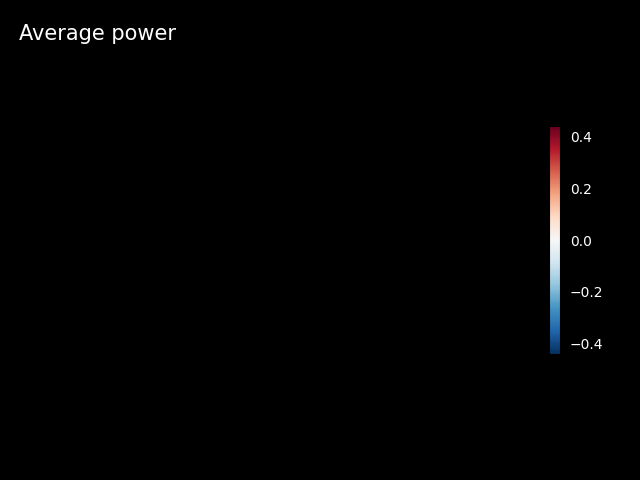

Applying baseline correction (mode: logratio)


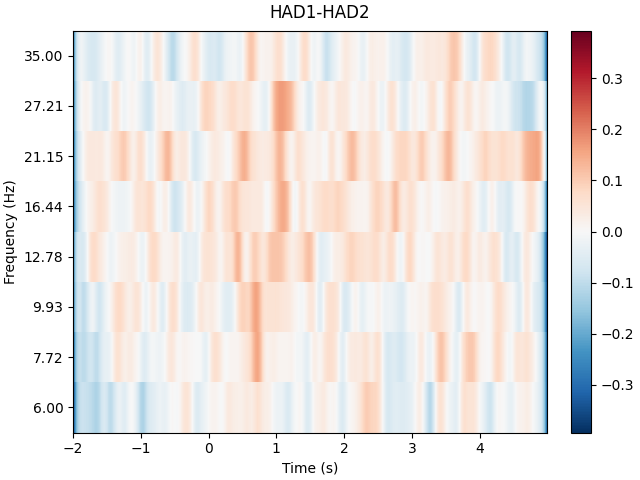

Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


In [ ]:
power.plot_topo(baseline=(-0.5, 0), mode="logratio", title="Average power")
power.plot(picks=[10], baseline=(-0.5, 0), mode="logratio", title=power.ch_names[10])

fig, axes = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
topomap_kw = dict(
    ch_type=None, tmin=0.5, tmax=1.5, baseline=(-0.5, 0), mode="logratio", show=False
)
plot_dict = dict(Alpha=dict(fmin=8, fmax=12), Beta=dict(fmin=13, fmax=25))
for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    power.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)
fig.savefig(f"figures/psd/{subject}_tfr_topomap_{reference}.png", dpi=300)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


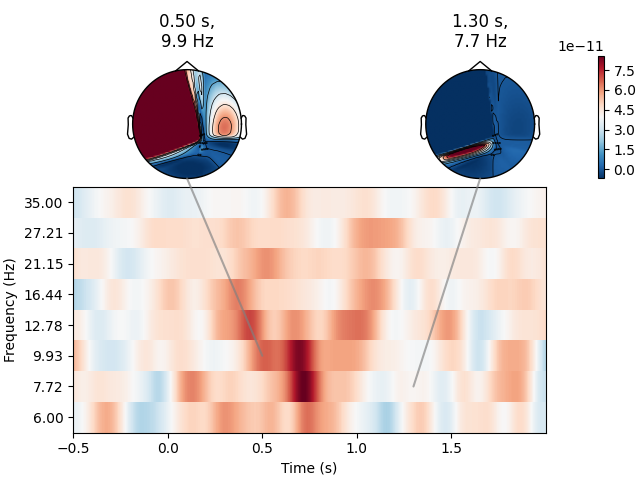

In [ ]:
power.plot_joint(
    baseline=(-0.5, 0), mode="mean", tmin=-0.5, tmax=2, timefreqs=[(0.5, 10), (1.3, 8)]
).savefig(f"figures/psd/{subject}_tfr_joint_{reference}.png", dpi=300)